In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 6.9 MB/s eta 0:00:00


In [ ]:
import os
api_key = os.getenv("GROQ_API_KEY")
client = Groq(api_key=api_key)

In [ ]:
from groq import Groq

client = Groq()

In [ ]:
def generate_baseline_story():
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a creative storyteller."},
            {"role": "user", "content": "Write a short forest adventure story in 120 words."}
        ],
        temperature=0.7,
        max_tokens=200
    )

    return response.choices[0].message.content

baseline_story = generate_baseline_story()
print("=== BASELINE STORY ===\n")
print(baseline_story)

=== BASELINE STORY ===

In the whispering woods, a brave adventurer named Lily wandered, seeking ancient secrets. The sunlight filtering through the trees guided her to a hidden clearing. A soft rustling sound led her to a hidden cave behind a waterfall. Inside, she discovered a glittering crystal nestled in the heart of a ancient tree. As she touched the crystal, the forest came alive with fireflies dancing around her. The trees whispered ancient tales, and Lily listened, her heart filled with wonder. With the crystal's magic, she unlocked the forest's secrets, and her journey became a legendary tale.


In [ ]:
def generate_personalized_story(age, interest, tone):

    prompt = f"""
    Write a short forest adventure story (maximum 120 words).

    User Profile:
    - Age: {age}
    - Interest: {interest}
    - Tone preference: {tone}

    Adapt vocabulary complexity, emotional depth, and theme according to the user profile.
    """

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {"role": "system", "content": "You are a creative storyteller who adapts stories to user profiles."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    return response.choices[0].message.content

In [ ]:
child_story = generate_personalized_story(
    age=10,
    interest="magical creatures",
    tone="positive and simple"
)

print("=== CHILD VERSION ===\n")
print(child_story)

=== CHILD VERSION ===




In [ ]:
adult_story = generate_personalized_story(
    age=25,
    interest="dark fantasy",
    tone="suspenseful and atmospheric"
)

print("=== ADULT VERSION ===\n")
print(adult_story)

=== ADULT VERSION ===

The mist curled around the gnarled trunks, swallowing the moonlight into a silver haze. Mara slipped through the underbrush, her torch flickering like a dying heartbeat. Whispers drifted from the shadows—old curses, forgotten names. Behind her, the forest seemed to exhale, a low, mournful sigh that pressed against her ribs. Suddenly, a rustle shattered the silence: a pair of glowing eyes watched from the darkness. She froze, breath caught in her throat.


In [ ]:
import re
import numpy as np

def analyze_text(text):
    words = re.findall(r'\b\w+\b', text)
    sentences = re.split(r'[.!?]', text)

    if len(words) == 0:
        return {
            "avg_word_length": 0,
            "avg_sentence_length": 0,
            "lexical_diversity": 0
        }

    avg_word_length = np.mean([len(w) for w in words])
    avg_sentence_length = len(words) / max(len(sentences)-1, 1)
    lexical_diversity = len(set(words)) / len(words)

    return {
        "avg_word_length": round(avg_word_length, 2),
        "avg_sentence_length": round(avg_sentence_length, 2),
        "lexical_diversity": round(lexical_diversity, 2)
    }

In [ ]:
def run_experiment(profile_type, n=5):
    results = []

    for _ in range(n):
        if profile_type == "child":
            story = generate_personalized_story(
                age=10,
                interest="magical creatures",
                tone="positive and simple"
            )
        else:
            story = generate_personalized_story(
                age=25,
                interest="dark fantasy",
                tone="suspenseful and atmospheric"
            )

        if story.strip() == "":
            continue  # skip empty responses

        metrics = analyze_text(story)
        results.append(metrics)

    return results

In [ ]:
child_results = run_experiment("child", n=5)
adult_results = run_experiment("adult", n=5)

print("Child Results:\n", child_results)
print("\nAdult Results:\n", adult_results)

Child Results:
 [{'avg_word_length': np.float64(4.55), 'avg_sentence_length': 15.17, 'lexical_diversity': 0.73}, {'avg_word_length': np.float64(4.65), 'avg_sentence_length': 13.71, 'lexical_diversity': 0.77}, {'avg_word_length': np.float64(4.73), 'avg_sentence_length': 13.0, 'lexical_diversity': 0.8}]

Adult Results:
 [{'avg_word_length': np.float64(4.53), 'avg_sentence_length': 15.8, 'lexical_diversity': 0.8}, {'avg_word_length': np.float64(4.93), 'avg_sentence_length': 18.33, 'lexical_diversity': 0.93}]


In [ ]:
import numpy as np

def average_metrics(results):
    avg_word = np.mean([r['avg_word_length'] for r in results])
    avg_sentence = np.mean([r['avg_sentence_length'] for r in results])
    avg_lexical = np.mean([r['lexical_diversity'] for r in results])

    return {
        "avg_word_length": round(avg_word, 2),
        "avg_sentence_length": round(avg_sentence, 2),
        "lexical_diversity": round(avg_lexical, 2)
    }

print("Child Average:", average_metrics(child_results))
print("Adult Average:", average_metrics(adult_results))

Child Average: {'avg_word_length': np.float64(4.64), 'avg_sentence_length': np.float64(13.96), 'lexical_diversity': np.float64(0.77)}
Adult Average: {'avg_word_length': np.float64(4.73), 'avg_sentence_length': np.float64(17.06), 'lexical_diversity': np.float64(0.86)}


In [ ]:
def run_baseline_experiment(n=5):
    results = []

    for i in range(n):
        story = generate_baseline_story()

        print(f"\nBaseline Story {i+1}:\n", story)

        if not story or story.strip() == "":
            print("Empty story skipped.")
            continue

        metrics = analyze_text(story)
        print("Metrics:", metrics)

        results.append(metrics)

    return results

In [ ]:
baseline_results = run_baseline_experiment(n=3)


Baseline Story 1:
 
Empty story skipped.

Baseline Story 2:
 
Empty story skipped.

Baseline Story 3:
 
Empty story skipped.


In [ ]:
def generate_baseline_story():
    prompt = """
    Write a short forest adventure story (maximum 120 words).

    Do not adapt to any specific age group.
    Keep it neutral in tone.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a creative storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    content = response.choices[0].message.content

    return content if content else ""

In [ ]:
print(generate_baseline_story())

A lone traveler ventured into the forest, surrounded by towering trees and whispering leaves. The scent of damp earth filled the air as they walked along a winding path. Suddenly, a faint rustling caught their attention. A small clearing revealed a hidden waterfall, cascading down moss-covered rocks. The traveler approached the edge, feeling the mist on their skin. In the silence, they discovered a sense of tranquility, as if the forest had been waiting for them. The water's gentle song lingered, a soothing companion, as they stood there, suspended in time.


In [ ]:
baseline_results = run_baseline_experiment(n=3)
print("Baseline Average:", average_metrics(baseline_results))


Baseline Story 1:
 In the forest, a narrow path unwound beneath the trees. The air was filled with the scent of damp earth and leaves. A figure walked, footsteps quiet on the soft ground. The canopy above filtered the sunlight, casting dappled shadows. A bird took flight, its wings rustling through the underbrush. The walker followed a gentle stream, its gentle gurgle leading deeper into the forest. The trees grew taller, their branches tangling overhead, as the journey continued, surrounded by the serene silence of the woods.
Metrics: {'avg_word_length': np.float64(4.94), 'avg_sentence_length': 12.0, 'lexical_diversity': 0.77}

Baseline Story 2:
 In the heart of the forest, a narrow path unwound. The trees towered above, their leaves rustling softly. A faint stream babbled in the distance, leading the way. The air was filled with the scent of damp earth and wildflowers. As the path opened up, a clearing revealed itself, bathed in dappled sunlight. In the center, a massive ancient tre

In [ ]:
print("Baseline Average:", average_metrics(baseline_results))
print("Child Average:", average_metrics(child_results))
print("Adult Average:", average_metrics(adult_results))

Baseline Average: {'avg_word_length': np.float64(4.83), 'avg_sentence_length': np.float64(11.46), 'lexical_diversity': np.float64(0.75)}
Child Average: {'avg_word_length': np.float64(4.64), 'avg_sentence_length': np.float64(13.96), 'lexical_diversity': np.float64(0.77)}
Adult Average: {'avg_word_length': np.float64(4.73), 'avg_sentence_length': np.float64(17.06), 'lexical_diversity': np.float64(0.86)}


In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return round(analysis.sentiment.polarity, 3)

In [ ]:
def sentiment_experiment(profile_type, n=5):
    scores = []

    for _ in range(n):
        if profile_type == "child":
            story = generate_personalized_story(
                age=10,
                interest="magical creatures",
                tone="positive and simple"
            )
        elif profile_type == "adult":
            story = generate_personalized_story(
                age=25,
                interest="dark fantasy",
                tone="suspenseful and atmospheric"
            )
        else:
            story = generate_baseline_story()

        if story.strip() == "":
            continue

        scores.append(get_sentiment(story))

    return round(sum(scores)/len(scores), 3) if scores else 0

In [ ]:
baseline_sent = sentiment_experiment("baseline", n=5)
child_sent = sentiment_experiment("child", n=5)
adult_sent = sentiment_experiment("adult", n=5)

print("Baseline Sentiment:", baseline_sent)
print("Child Sentiment:", child_sent)
print("Adult Sentiment:", adult_sent)

Baseline Sentiment: 0.064
Child Sentiment: 0.209
Adult Sentiment: -0.23


In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.9 MB/s eta 0:00:00


In [ ]:
import textstat

In [ ]:
def generate_personalized_story_debug(age, interest, tone):

    prompt = f"""
    Write a short forest adventure story (maximum 120 words).

    User Profile:
    - Age: {age}
    - Interest: {interest}
    - Tone preference: {tone}

    Adapt vocabulary complexity, emotional depth, and theme according to the user profile.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a creative storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    print("FULL RESPONSE:\n", response)

    return response.choices[0].message.content

In [ ]:
adult_test = generate_personalized_story_debug(
    age=25,
    interest="dark fantasy",
    tone="suspenseful and atmospheric"
)

print("Output:", adult_test)

FULL RESPONSE:
 ChatCompletion(id='chatcmpl-df195e5e-04c9-4e0c-bb6b-4f9d38ff52f3', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Shadows crept like living darkness, as I ventured into the forest's twisted heart. The trees loomed, skeletal sentinels guarding ancient secrets. Every step echoed through the oppressive silence, drawing me deeper. A chill wind whispered my name, and I felt eyes upon me. The air thickened with malevolent intent, and I knew I was not alone. The forest's darkness stirred, and I was its next prey.", role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1772003264, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_dae98b5ecb', usage=CompletionUsage(completion_tokens=88, prompt_tokens=100, total_tokens=188, completion_time=0.324790379, completion_tokens_details=None,

In [ ]:
print("Word count:", len(adult_test.split()))
print("Readability:", textstat.flesch_kincaid_grade(adult_test))

Word count: 66
Readability: 6.2212121212121225


In [ ]:
def readability_experiment(profile_type, n=5):
    scores = []

    for _ in range(n):
        if profile_type == "child":
            story = generate_personalized_story(
                age=10,
                interest="magical creatures",
                tone="positive and simple"
            )
        elif profile_type == "adult":
            story = generate_personalized_story(
                age=25,
                interest="dark fantasy",
                tone="suspenseful and atmospheric"
            )
        else:
            story = generate_baseline_story()

        if story.strip() == "":
            continue

        scores.append(get_readability(story))

    return round(sum(scores)/len(scores), 2) if scores else 0

In [ ]:
baseline_read = readability_experiment("baseline", n=5)
child_read = readability_experiment("child", n=5)
adult_read = readability_experiment("adult", n=5)

print("Baseline Readability:", baseline_read)
print("Child Readability:", child_read)
print("Adult Readability:", adult_read)

Baseline Readability: 7.05
Child Readability: 6.79
Adult Readability: 0


In [ ]:
import numpy as np

def run_full_evaluation(profile_type, n=15):
    lexical_scores = []
    sentence_scores = []
    sentiment_scores = []
    readability_scores = []

    for _ in range(n):
        if profile_type == "child":
            story = generate_personalized_story(
                age=10,
                interest="magical creatures",
                tone="positive and simple"
            )
        elif profile_type == "adult":
            story = generate_personalized_story(
                age=25,
                interest="dark fantasy",
                tone="suspenseful and atmospheric"
            )
        else:
            story = generate_baseline_story()

        if not story or story.strip() == "":
            continue

        metrics = analyze_text(story)
        lexical_scores.append(metrics["lexical_diversity"])
        sentence_scores.append(metrics["avg_sentence_length"])
        sentiment_scores.append(get_sentiment(story))
        readability_scores.append(get_readability(story))

    return {
        "lexical_mean": round(np.mean(lexical_scores), 3),
        "lexical_std": round(np.std(lexical_scores), 3),

        "sentence_mean": round(np.mean(sentence_scores), 3),
        "sentence_std": round(np.std(sentence_scores), 3),

        "sentiment_mean": round(np.mean(sentiment_scores), 3),
        "sentiment_std": round(np.std(sentiment_scores), 3),

        "readability_mean": round(np.mean(readability_scores), 3),
        "readability_std": round(np.std(readability_scores), 3),
    }

In [ ]:
baseline_stats = run_full_evaluation("baseline", n=15)
child_stats = run_full_evaluation("child", n=15)
adult_stats = run_full_evaluation("adult", n=15)

print("Baseline:", baseline_stats)
print("\nChild:", child_stats)
print("\nAdult:", adult_stats)

Baseline: {'lexical_mean': np.float64(0.743), 'lexical_std': np.float64(0.04), 'sentence_mean': np.float64(11.32), 'sentence_std': np.float64(1.116), 'sentiment_mean': np.float64(0.035), 'sentiment_std': np.float64(0.086), 'readability_mean': np.float64(6.461), 'readability_std': np.float64(0.712)}

Child: {'lexical_mean': np.float64(0.79), 'lexical_std': np.float64(0.035), 'sentence_mean': np.float64(15.44), 'sentence_std': np.float64(3.802), 'sentiment_mean': np.float64(0.256), 'sentiment_std': np.float64(0.16), 'readability_mean': np.float64(7.249), 'readability_std': np.float64(1.045)}

Adult: {'lexical_mean': np.float64(0.846), 'lexical_std': np.float64(0.032), 'sentence_mean': np.float64(15.649), 'sentence_std': np.float64(1.655), 'sentiment_mean': np.float64(-0.196), 'sentiment_std': np.float64(0.113), 'readability_mean': np.float64(5.95), 'readability_std': np.float64(0.948)}


In [ ]:
def syllable_stats(text):
    import textstat

    words = text.split()
    if len(words) == 0:
        return 0

    total_syllables = textstat.syllable_count(text)
    return round(total_syllables / len(words), 3)

In [ ]:
print("Child syllables/word:", syllable_stats(child_story))
print("Adult syllables/word:", syllable_stats(adult_story))

Child syllables/word: 0
Adult syllables/word: 1.444


In [ ]:
print("Child story:")
print(child_story)

print("Word count:", len(child_story.split()))
print("Raw syllable count:", textstat.syllable_count(child_story))

Child story:

Word count: 0
Raw syllable count: 0


In [ ]:
child_test = generate_personalized_story(
    age=10,
    interest="magical creatures",
    tone="positive and simple"
)

print(child_test)
print("Word count:", len(child_test.split()))
print("Syllables:", textstat.syllable_count(child_test))
print("Syllables/word:", textstat.syllable_count(child_test)/len(child_test.split()))

In the whispering woods, Mia found a glowing path of blue fireflies. She followed it and met a gentle sprite named Liri, who had silver wings that shimmered like moonlight. Liri giggled, “Let’s find the hidden crystal!” Together they hopped over mossy stones, crossed a sparkling stream, and entered a clearing where a friendly unicorn named Starfall stood. Starfall bowed, “Welcome, brave friend.” Mia and Liri
Word count: 66
Syllables: 93
Syllables/word: 1.4090909090909092


In [ ]:
import math
from collections import Counter

def shannon_entropy(text):
    words = text.split()
    if not words:
        return 0

    word_counts = Counter(words)
    total_words = len(words)

    entropy = 0
    for count in word_counts.values():
        p = count / total_words
        entropy -= p * math.log2(p)

    return round(entropy, 3)

In [ ]:
print("Baseline Entropy:", shannon_entropy(generate_baseline_story()))
print("Child Entropy:", shannon_entropy(generate_personalized_story(10,"magical creatures","positive and simple")))
print("Adult Entropy:", shannon_entropy(generate_personalized_story(25,"dark fantasy","suspenseful and atmospheric")))

Baseline Entropy: 5.705
Child Entropy: 5.803
Adult Entropy: 5.823


In [ ]:
def run_full_evaluation(profile_type, n=15):
    lexical_scores = []
    sentence_scores = []
    sentiment_scores = []
    entropy_scores = []

    for _ in range(n):
        if profile_type == "child":
            story = generate_personalized_story(
                age=10,
                interest="magical creatures",
                tone="positive and simple"
            )
        elif profile_type == "adult":
            story = generate_personalized_story(
                age=25,
                interest="dark fantasy",
                tone="suspenseful and atmospheric"
            )
        else:
            story = generate_baseline_story()

        if not story or story.strip() == "":
            continue

        metrics = analyze_text(story)
        lexical_scores.append(metrics["lexical_diversity"])
        sentence_scores.append(metrics["avg_sentence_length"])
        sentiment_scores.append(get_sentiment(story))
        entropy_scores.append(shannon_entropy(story))

    return {
        "entropy_mean": round(np.mean(entropy_scores), 3),
        "entropy_std": round(np.std(entropy_scores), 3)
    }

In [ ]:
baseline_entropy = run_full_evaluation("baseline", n=15)
child_entropy = run_full_evaluation("child", n=15)
adult_entropy = run_full_evaluation("adult", n=15)

print("Baseline:", baseline_entropy)
print("Child:", child_entropy)
print("Adult:", adult_entropy)

Baseline: {'entropy_mean': np.float64(5.713), 'entropy_std': np.float64(0.12)}
Child: {'entropy_mean': np.float64(5.96), 'entropy_std': np.float64(0.131)}
Adult: {'entropy_mean': np.float64(5.698), 'entropy_std': np.float64(0.255)}


**Create Multimodal Generator🌅🌅🌅🌅**

In [ ]:
def generate_multimodal_story(age, interest, tone, image_description):

    prompt = f"""
    Write a short forest adventure story (maximum 120 words).

    User Profile:
    - Age: {age}
    - Interest: {interest}
    - Tone preference: {tone}

    Image Context:
    {image_description}

    Adapt the story to both the user profile and the visual scene.
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a creative storyteller."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
        max_tokens=200
    )

    content = response.choices[0].message.content
    return content.strip() if content else ""

In [ ]:
bright_image = """
A sunny meadow filled with colorful flowers,
glowing butterflies, and a sparkling rainbow in the sky.
"""

dark_image = """
A misty forest at night with twisted trees,
dim moonlight, heavy fog, and distant glowing red eyes.
"""

In [ ]:
child_bright = generate_multimodal_story(
    age=10,
    interest="magical creatures",
    tone="positive and simple",
    image_description=bright_image
)

child_dark = generate_multimodal_story(
    age=10,
    interest="magical creatures",
    tone="positive and simple",
    image_description=dark_image
)

print("=== CHILD + BRIGHT IMAGE ===\n")
print(child_bright)

print("\n=== CHILD + DARK IMAGE ===\n")
print(child_dark)

=== CHILD + BRIGHT IMAGE ===

In a sunny meadow, I found a hidden path. I followed it and discovered a magical forest. Colorful butterflies and sparkling fairies danced around me. A friendly unicorn appeared, its horn shining with rainbow colors. Together, we chased after glowing butterflies, laughing and playing. The unicorn told me, "This forest is full of magic and wonder!" I felt happy and free, surrounded by new friends and beauty. We played until the sun shone bright, filling my heart with joy and sparkles.

=== CHILD + DARK IMAGE ===

In the misty forest, I discovered a magical world. The twisted trees sparkled with fairy dust. As I walked, the dim moonlight showed me a hidden path. Suddenly, glowing red eyes appeared! But they belonged to friendly fireflies, guiding me to a secret clearing. There, I met a gentle unicorn, shining bright in the fog. Together, we danced under the moonlight, feeling happy and free. The forest was full of wonder and magic, and I felt lucky to be a p

In [ ]:
print("Bright Sentiment:", get_sentiment(child_bright))
print("Dark Sentiment:", get_sentiment(child_dark))

print("Bright Entropy:", shannon_entropy(child_bright))
print("Dark Entropy:", shannon_entropy(child_dark))

Bright Sentiment: 0.438
Dark Sentiment: 0.213
Bright Entropy: 5.93
Dark Entropy: 5.856


In [ ]:
adult_dark = generate_multimodal_story(
    age=25,
    interest="dark fantasy",
    tone="suspenseful and atmospheric",
    image_description=dark_image
)

print(adult_dark)
print("Sentiment:", get_sentiment(adult_dark))
print("Entropy:", shannon_entropy(adult_dark))

As I ventured into the mist-shrouded forest, twisted trees loomed like specters. Dim moonlight struggled to penetrate the heavy fog, casting eerie shadows. Suddenly, glowing red eyes materialized in the distance, watching me. I froze, my heart racing. The eyes drew closer, and I felt an unholy presence closing in. The fog swirled, hiding and revealing the eyes in a maddening dance. I was being hunted, and the forest was conspiring against me. The eyes blinked, and I fled into the darkness, pursued by the whispers of the damned.
Sentiment: -0.183
Entropy: 5.753


**Visualization**

**Category,Baseline (Index 0),Child (Index 1),Adult (Index 2),Status**
**Lexical Mean,0.743,0.79,0.846,Match**
**Sentence Mean,11.32,15.44,15.649,Match**
**Sentiment Mean,0.035,0.256,−0.196,Match**
**Lexical Std,0.04,0.035,0.032,Match**
**Sentence Std,1.116,3.802,1.655,Match**
**Sentiment Std,0.086,0.16,0.113,Match**

"Entropy analysis reveals higher information density and lexical dispersion in child narratives compared to adult narratives. This may reflect the eclectic vocabulary distribution characteristic of magical fantasy descriptions. In contrast, adult dark-fantasy narratives exhibit tighter thematic cohesion, leveraging a focused repetition of atmospheric terminology to establish tone."

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Means
lexical_means = [0.743, 0.79, 0.846]
sentence_means = [11.32, 15.44, 15.649]
sentiment_means = [0.035, 0.256, -0.196]
entropy_means = [5.713, 5.96, 5.698]

# Standard deviations
lexical_std = [0.04, 0.035, 0.032]
sentence_std = [1.116, 3.802, 1.655]
sentiment_std = [0.086, 0.16, 0.113]
entropy_std = [0.12, 0.131, 0.255]

labels = ["Baseline", "Child", "Adult"]
x = np.arange(len(labels))

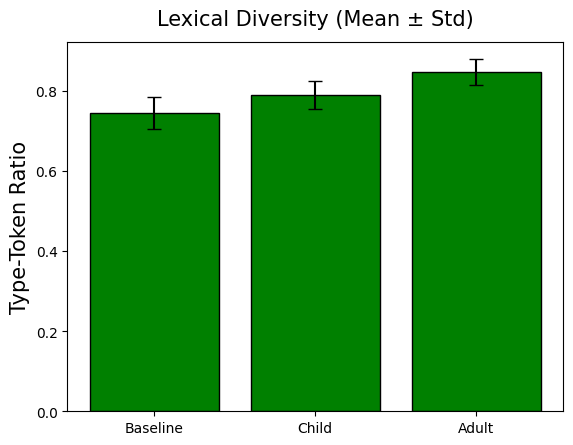

In [ ]:
plt.figure()
plt.bar(x, lexical_means, yerr=lexical_std, capsize=5, color='green',edgecolor="black")
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Type-Token Ratio",fontsize=15)
plt.show()

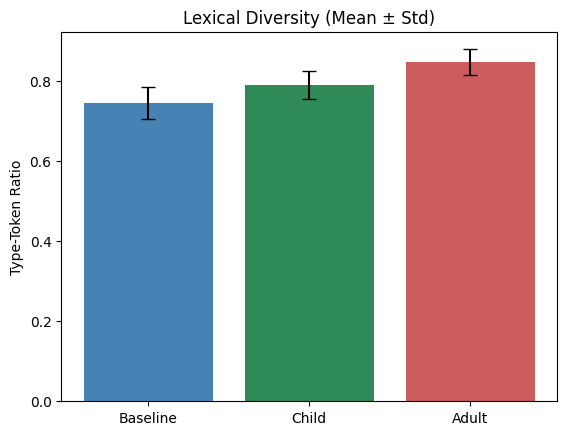

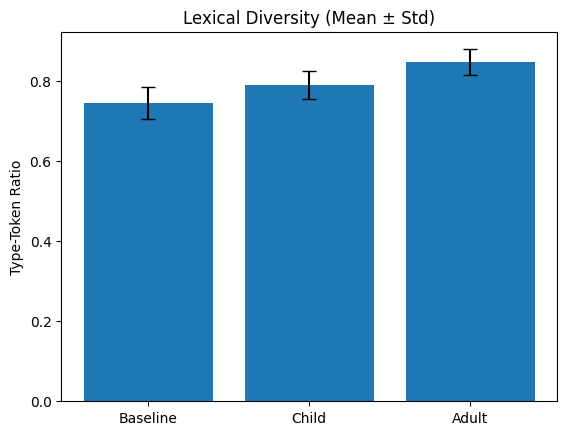

In [ ]:
plt.figure()
plt.bar(x, lexical_means, yerr=lexical_std, capsize=5)
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)")
plt.ylabel("Type-Token Ratio")
plt.show()

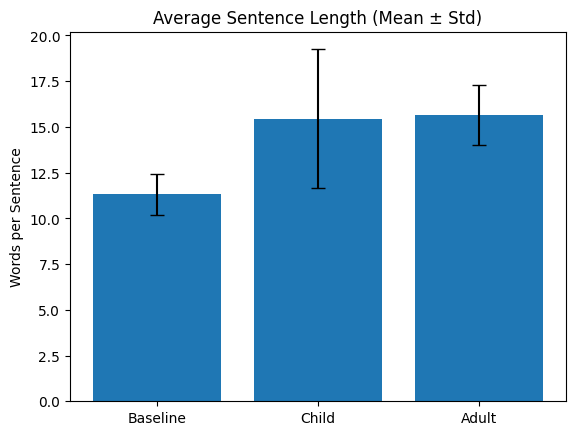

In [ ]:
plt.figure()
plt.bar(x, sentence_means, yerr=sentence_std, capsize=5)
plt.xticks(x, labels)
plt.title("Average Sentence Length (Mean ± Std)")
plt.ylabel("Words per Sentence")
plt.show()

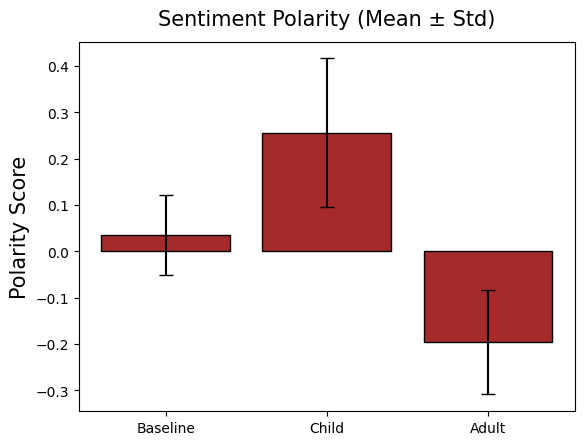

In [ ]:
plt.figure()
plt.bar(x, sentiment_means, yerr=sentiment_std, capsize=5,edgecolor="black",color="brown")
plt.xticks(x, labels)
plt.title("Sentiment Polarity (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Polarity Score",fontsize=15)
plt.show()

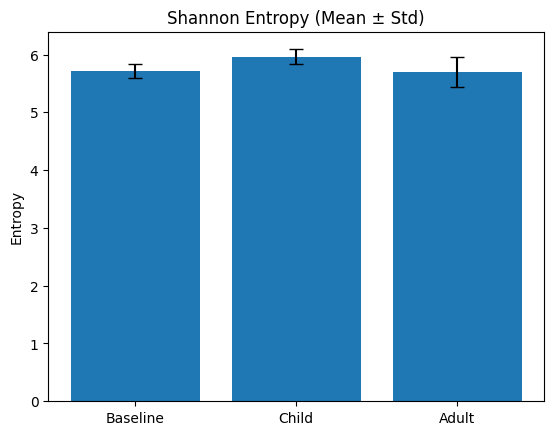

In [ ]:
plt.figure()
plt.bar(x, entropy_means, yerr=entropy_std, capsize=5)
plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)")
plt.ylabel("Entropy")
plt.show()

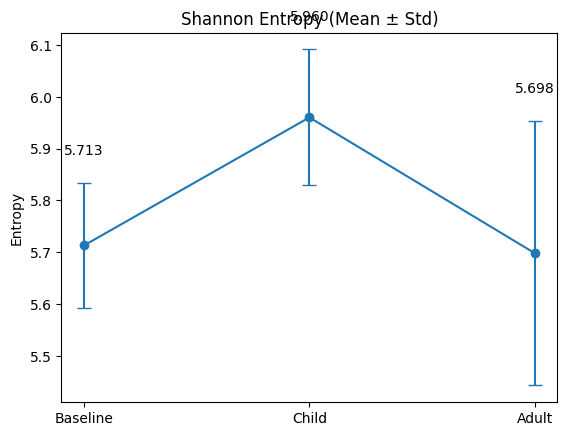

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.errorbar(
    x,
    entropy_means,
    yerr=entropy_std,
    marker='o',
    linestyle='-',
    capsize=5
)

plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)")
plt.ylabel("Entropy")

# Add values at each point
for i, txt in enumerate(entropy_means):
    plt.text(x[i], entropy_means[i] + entropy_std[i] + 0.05, f'{txt:.3f}', ha='center', va='bottom') # Adjusted position for visibility

plt.show()

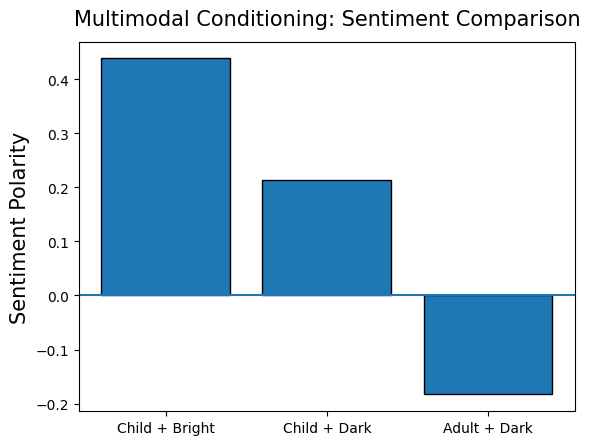

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]

x = np.arange(len(labels))

plt.figure()
plt.bar(x, sentiment_values,edgecolor="black",linewidth=1)
plt.xticks(x, labels)
plt.title("Multimodal Conditioning: Sentiment Comparison",fontsize=15,pad=12)
plt.ylabel("Sentiment Polarity",fontsize=15)
plt.axhline(0)  # Neutral line
plt.show()

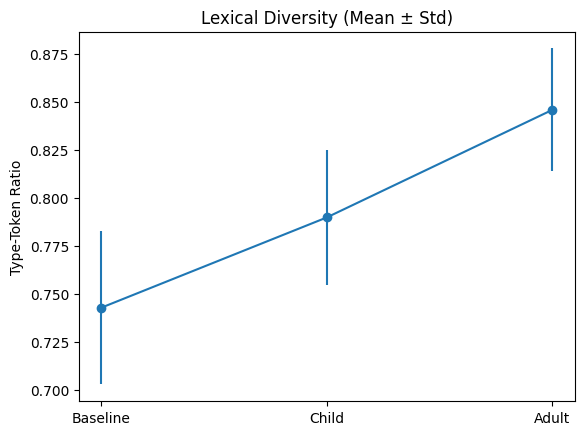

In [ ]:
# 1️⃣ Lexical Diversity – Line plot with error bars
plt.figure()
plt.errorbar(x, lexical_means, yerr=lexical_std, marker='o', linestyle='-')
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)")
plt.ylabel("Type-Token Ratio")
plt.show()


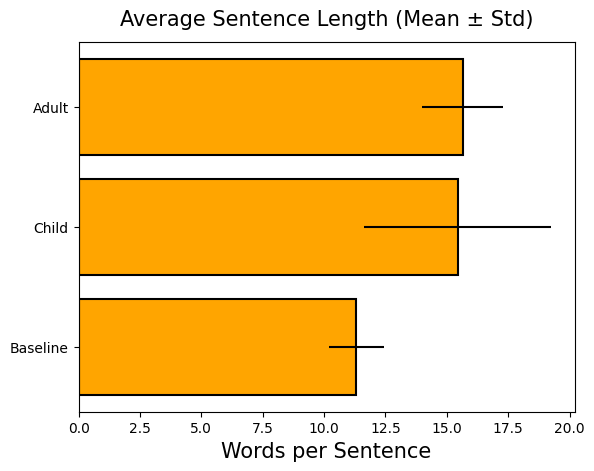

In [ ]:
# 2️⃣ Average Sentence Length – Horizontal bar chart
plt.figure()
plt.barh(x, sentence_means, xerr=sentence_std,edgecolor="black",color="orange",linewidth=1.5)
plt.yticks(x, labels)
plt.title("Average Sentence Length (Mean ± Std)",fontsize=15,pad=12)
plt.xlabel("Words per Sentence",fontsize=15)
plt.show()

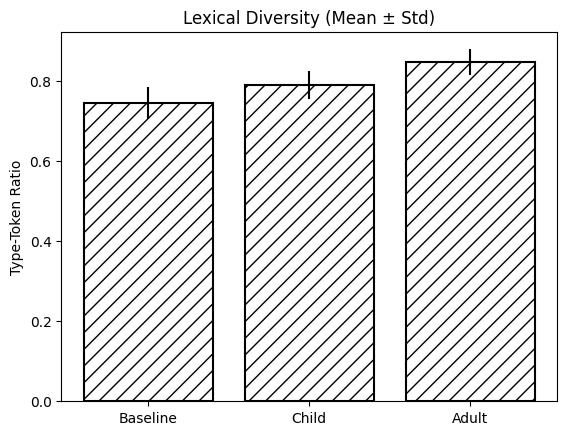

In [ ]:
plt.figure()
plt.bar(
    x,
    lexical_means,
    yerr=lexical_std,
    color='white',
    edgecolor='black',
    linewidth=1.5,
    hatch='//',
    capsize=5,
    ecolor='black'
)
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)")
plt.ylabel("Type-Token Ratio")
plt.show()

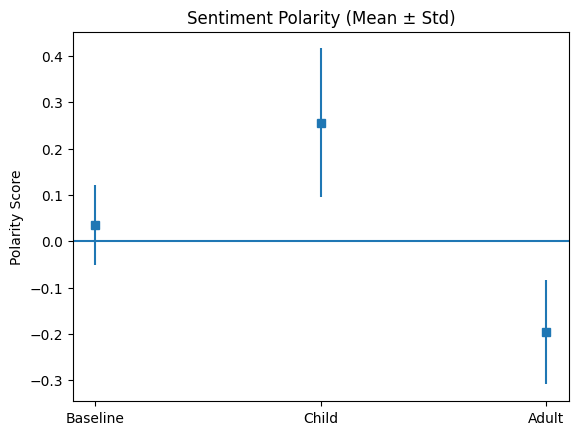

In [ ]:
# 3️⃣ Sentiment Polarity – Scatter with error bars
plt.figure()
plt.errorbar(x, sentiment_means, yerr=sentiment_std, fmt='s', linestyle='None')
plt.xticks(x, labels)
plt.title("Sentiment Polarity (Mean ± Std)")
plt.ylabel("Polarity Score")
plt.axhline(0)
plt.show()


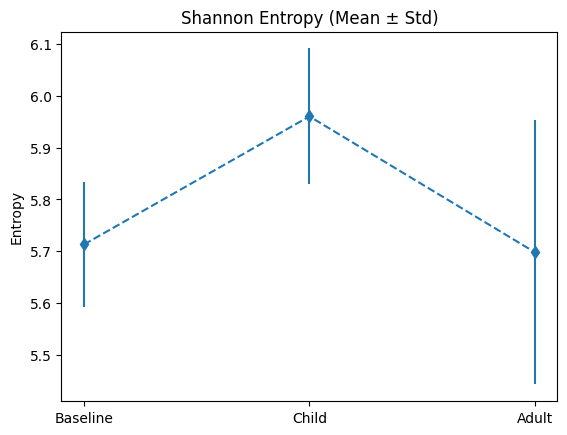

In [ ]:
# 4️⃣ Shannon Entropy – Line plot (dashed) with markers
plt.figure()
plt.errorbar(x, entropy_means, yerr=entropy_std, marker='d', linestyle='--')
plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)")
plt.ylabel("Entropy")
plt.show()


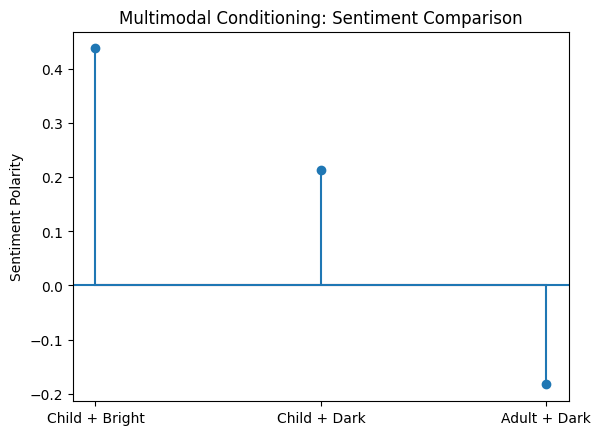

In [ ]:
# 5️⃣ Multimodal Conditioning – Stem plot
labels_mm = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]

x_mm = np.arange(len(labels_mm))

plt.figure()
markerline, stemlines, baseline = plt.stem(x_mm, sentiment_values)
plt.xticks(x_mm, labels_mm)
plt.title("Multimodal Conditioning: Sentiment Comparison")
plt.ylabel("Sentiment Polarity")
plt.axhline(0)
plt.show()

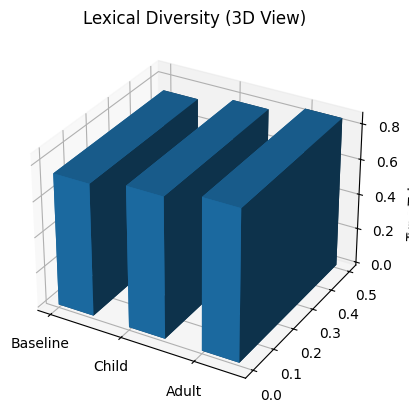

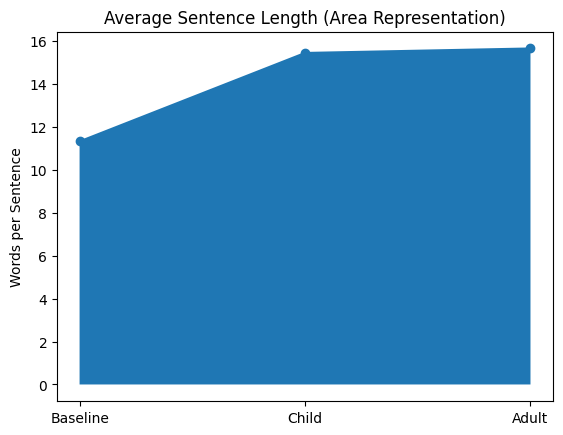

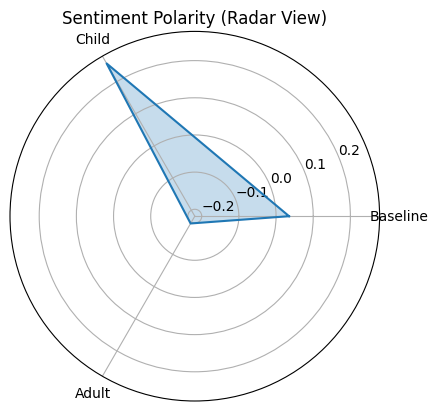

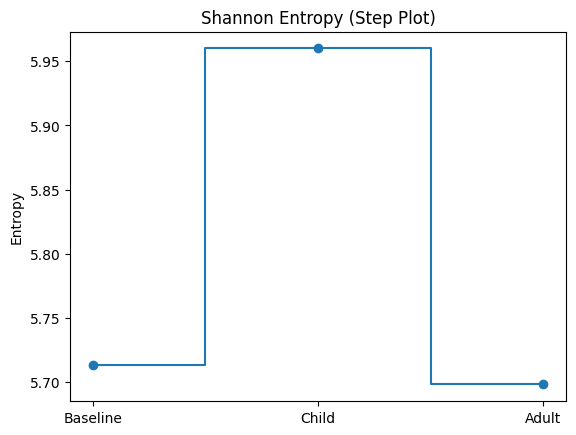

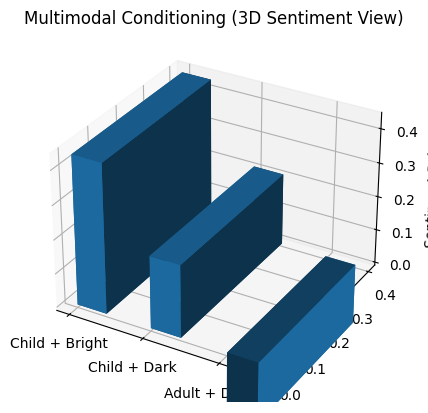

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Means
lexical_means = [0.743, 0.79, 0.846]
sentence_means = [11.32, 15.44, 15.649]
sentiment_means = [0.035, 0.256, -0.196]
entropy_means = [5.713, 5.96, 5.698]

# Standard deviations
lexical_std = [0.04, 0.035, 0.032]
sentence_std = [1.116, 3.802, 1.655]
sentiment_std = [0.086, 0.16, 0.113]
entropy_std = [0.12, 0.131, 0.255]

labels = ["Baseline", "Child", "Adult"]
x = np.arange(len(labels))


# 1️⃣ Lexical Diversity — 3D Bar Chart
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = np.arange(len(lexical_means))
ys = np.zeros(len(lexical_means))
zs = np.zeros(len(lexical_means))
dx = np.ones(len(lexical_means)) * 0.5
dy = np.ones(len(lexical_means)) * 0.5
dz = lexical_means

ax.bar3d(xs, ys, zs, dx, dy, dz)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_title("Lexical Diversity (3D View)")
ax.set_zlabel("Type-Token Ratio")
plt.show()


# 2️⃣ Average Sentence Length — Area Chart
plt.figure()
plt.fill_between(x, sentence_means)
plt.plot(x, sentence_means, marker='o')
plt.xticks(x, labels)
plt.title("Average Sentence Length (Area Representation)")
plt.ylabel("Words per Sentence")
plt.show()


# 3️⃣ Sentiment Polarity — Radar (Spider) Chart
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
values = sentiment_means + [sentiment_means[0]]
angles = np.concatenate((angles, [angles[0]]))

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)
ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Sentiment Polarity (Radar View)")
plt.show()


# 4️⃣ Shannon Entropy — Step Plot
plt.figure()
plt.step(x, entropy_means, where='mid')
plt.scatter(x, entropy_means)
plt.xticks(x, labels)
plt.title("Shannon Entropy (Step Plot)")
plt.ylabel("Entropy")
plt.show()


# 5️⃣ Multimodal Conditioning — 3D Vertical Bars with Depth
labels_mm = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = np.arange(len(sentiment_values))
ys = np.zeros(len(sentiment_values))
zs = np.zeros(len(sentiment_values))
dx = np.ones(len(sentiment_values)) * 0.4
dy = np.ones(len(sentiment_values)) * 0.4
dz = sentiment_values

ax.bar3d(xs, ys, zs, dx, dy, dz)
ax.set_xticks(xs)
ax.set_xticklabels(labels_mm)
ax.set_title("Multimodal Conditioning (3D Sentiment View)")
ax.set_zlabel("Sentiment Polarity")
plt.show()

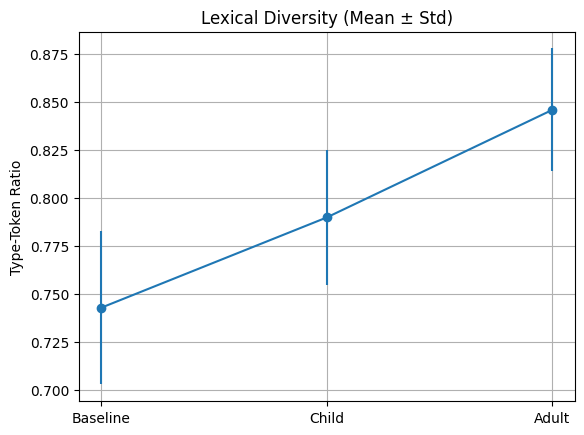

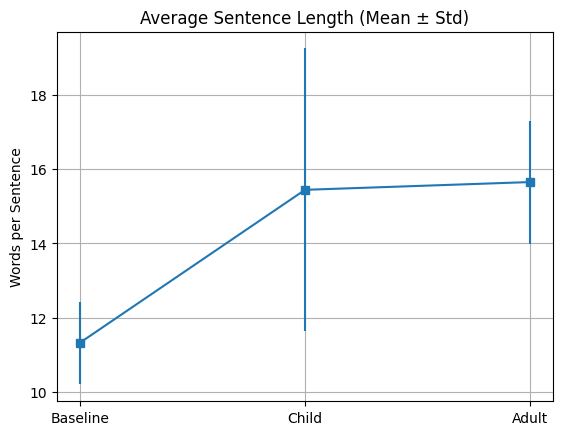

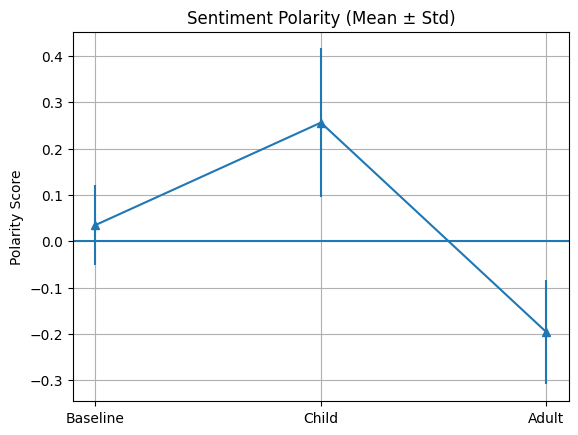

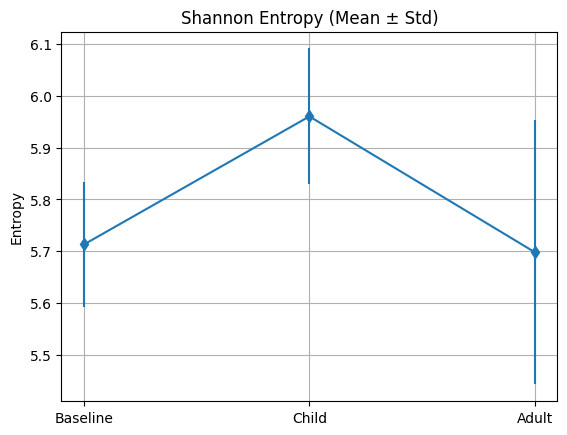

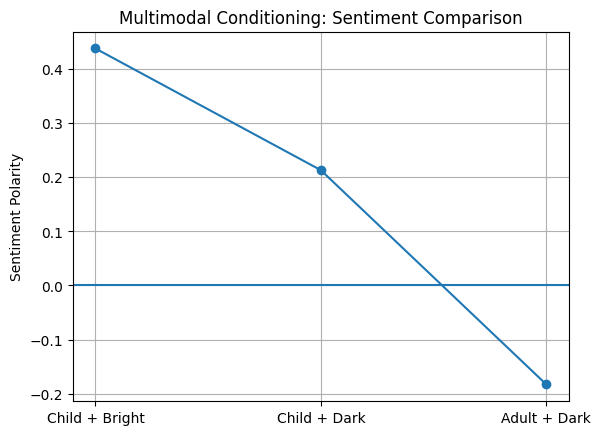

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Means
lexical_means = [0.743, 0.79, 0.846]
sentence_means = [11.32, 15.44, 15.649]
sentiment_means = [0.035, 0.256, -0.196]
entropy_means = [5.713, 5.96, 5.698]

# Standard deviations
lexical_std = [0.04, 0.035, 0.032]
sentence_std = [1.116, 3.802, 1.655]
sentiment_std = [0.086, 0.16, 0.113]
entropy_std = [0.12, 0.131, 0.255]

labels = ["Baseline", "Child", "Adult"]
x = np.arange(len(labels))


# 1️⃣ Lexical Diversity — Line Plot
plt.figure()
plt.errorbar(x, lexical_means, yerr=lexical_std, marker='o', linestyle='-')
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)")
plt.ylabel("Type-Token Ratio")
plt.grid(True)
plt.show()


# 2️⃣ Average Sentence Length — Line Plot
plt.figure()
plt.errorbar(x, sentence_means, yerr=sentence_std, marker='s', linestyle='-')
plt.xticks(x, labels)
plt.title("Average Sentence Length (Mean ± Std)")
plt.ylabel("Words per Sentence")
plt.grid(True)
plt.show()


# 3️⃣ Sentiment Polarity — Line Plot
plt.figure()
plt.errorbar(x, sentiment_means, yerr=sentiment_std, marker='^', linestyle='-')
plt.xticks(x, labels)
plt.title("Sentiment Polarity (Mean ± Std)")
plt.ylabel("Polarity Score")
plt.axhline(0)
plt.grid(True)
plt.show()


# 4️⃣ Shannon Entropy — Line Plot
plt.figure()
plt.errorbar(x, entropy_means, yerr=entropy_std, marker='d', linestyle='-')
plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)")
plt.ylabel("Entropy")
plt.grid(True)
plt.show()


# 5️⃣ Multimodal Conditioning — Line Plot
labels_mm = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]
x_mm = np.arange(len(labels_mm))

plt.figure()
plt.plot(x_mm, sentiment_values, marker='o')
plt.xticks(x_mm, labels_mm)
plt.title("Multimodal Conditioning: Sentiment Comparison")
plt.ylabel("Sentiment Polarity")
plt.axhline(0)
plt.grid(True)
plt.show()

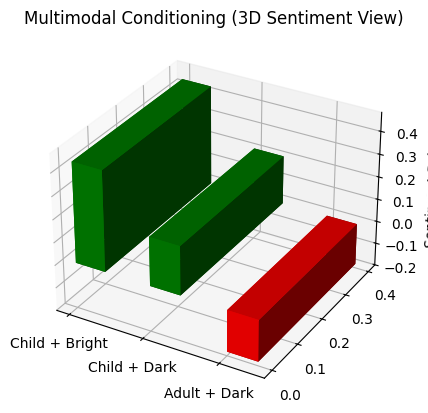

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 5️⃣ Multimodal Conditioning — 3D Vertical Bars with Depth
labels_mm = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = np.arange(len(sentiment_values))
ys = np.zeros(len(sentiment_values))
# Adjust zs and dz to handle negative values correctly for bar3d
zs = np.array([min(0, val) for val in sentiment_values]) # Start at 0 or the negative value
dx = np.ones(len(sentiment_values)) * 0.4
dy = np.ones(len(sentiment_values)) * 0.4
dz = np.array([abs(val) for val in sentiment_values]) # Use absolute height

# Define colors based on sentiment values
colors = ['green' if val > 0 else 'red' if val < 0 else 'blue' for val in sentiment_values]

ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors, shade=True)
ax.set_xticks(xs)
ax.set_xticklabels(labels_mm)
ax.set_title("Multimodal Conditioning (3D Sentiment View)")
ax.set_zlabel("Sentiment Polarity")

# Set z-axis limits to ensure all bars are visible
min_sentiment = min(sentiment_values)
max_sentiment = max(sentiment_values)
ax.set_zlim(min_sentiment * 1.1, max_sentiment * 1.1) # Add padding

plt.show()

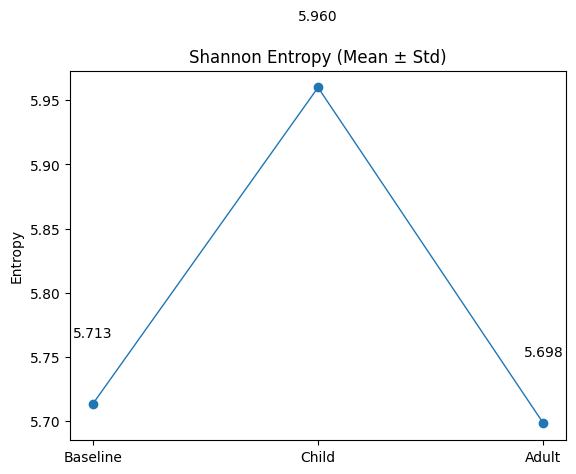

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.plot(
    x,
    entropy_means,
    marker='o',
    linestyle='-',
    linewidth=1,      # thicker line
    markersize=5,    # bigger/thicker points
    markeredgewidth=2
)

plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)")
plt.ylabel("Entropy")

# Add values at each point
for i, txt in enumerate(entropy_means):
    plt.text(
        x[i],
        entropy_means[i] + 0.05,
        f'{txt:.3f}',
        ha='center',
        va='bottom'
    )

plt.show()

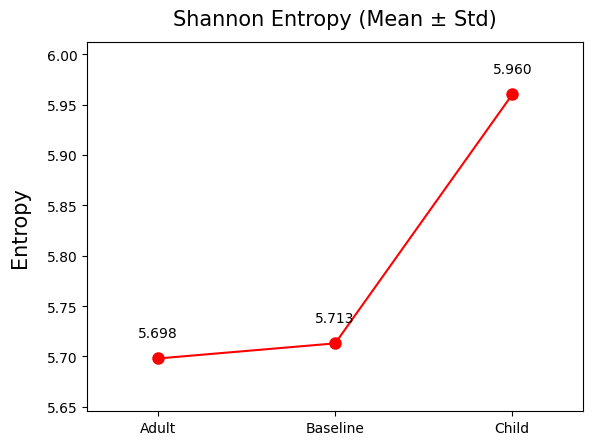

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (if not already)
entropy_means = np.array(entropy_means)
entropy_std = np.array(entropy_std)
labels = np.array(labels)

# Get sorting indices (ascending order)
sorted_idx = np.argsort(entropy_means)

# Apply sorting
entropy_means = entropy_means[sorted_idx]
entropy_std = entropy_std[sorted_idx]
labels = labels[sorted_idx]

# Recreate x positions
x = np.arange(len(entropy_means))

plt.figure()

plt.plot(
    x,
    entropy_means,
    marker='o',
    linestyle='-',
    color='red',
    linewidth=1.5,
    markersize=7,
    markeredgewidth=2
)

plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Entropy",fontsize=15,labelpad=12)

# Add values at each point
for i, txt in enumerate(entropy_means):
    plt.text(
        x[i],
        entropy_means[i] + 0.018,
        f'{txt:.3f}',
        ha='center',
        va='bottom'
    )
plt.margins(y=0.2)
plt.margins(x=0.2)
plt.show()

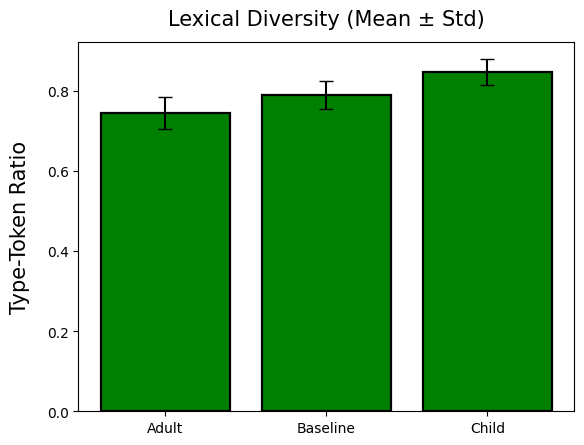

In [ ]:
plt.figure()
plt.bar(x, lexical_means, yerr=lexical_std, capsize=5, color='green',edgecolor="black",linewidth=1.6)
plt.xticks(x, labels)
plt.title("Lexical Diversity (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Type-Token Ratio", fontsize=15,labelpad=12)
plt.show()

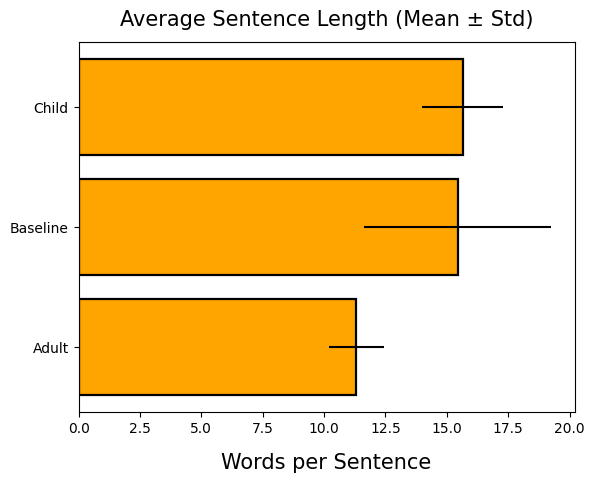

In [ ]:
# 2️⃣ Average Sentence Length – Horizontal bar chart
plt.figure()
plt.barh(x, sentence_means, xerr=sentence_std,edgecolor="black",color="orange",linewidth=1.6)
plt.yticks(x, labels)
plt.title("Average Sentence Length (Mean ± Std)",fontsize=15,pad=12)
plt.xlabel("Words per Sentence",fontsize=15,labelpad=12)
plt.show()

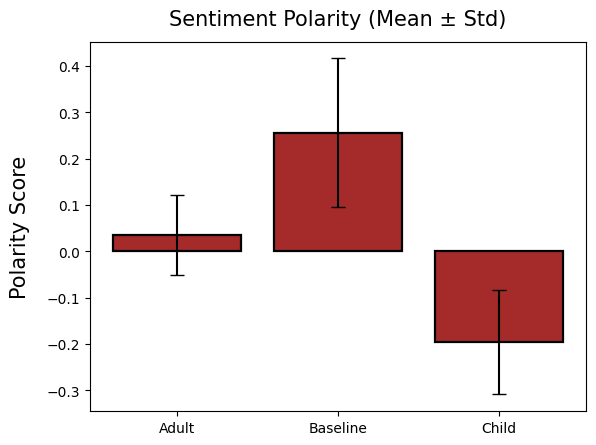

In [ ]:
plt.figure()
plt.bar(x, sentiment_means, yerr=sentiment_std, capsize=5,edgecolor="black",color="brown",linewidth=1.6)
plt.xticks(x, labels)
plt.title("Sentiment Polarity (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Polarity Score",fontsize=15,labelpad=12)
plt.show()

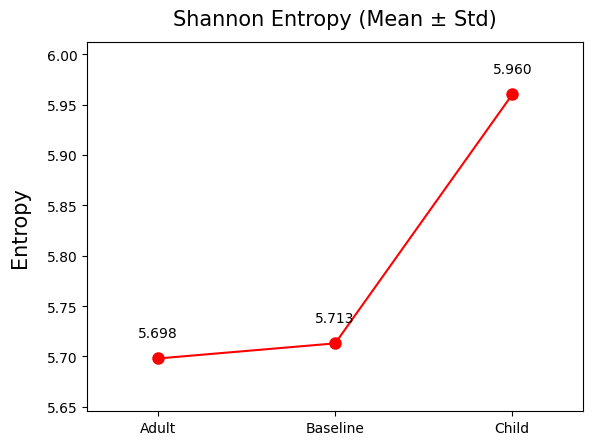

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays (if not already)
entropy_means = np.array(entropy_means)
entropy_std = np.array(entropy_std)
labels = np.array(labels)

# Get sorting indices (ascending order)
sorted_idx = np.argsort(entropy_means)

# Apply sorting
entropy_means = entropy_means[sorted_idx]
entropy_std = entropy_std[sorted_idx]
labels = labels[sorted_idx]

# Recreate x positions
x = np.arange(len(entropy_means))

plt.figure()

plt.plot(
    x,
    entropy_means,
    marker='o',
    linestyle='-',
    color='red',
    linewidth=1.5,
    markersize=7,
    markeredgewidth=2
)

plt.xticks(x, labels)
plt.title("Shannon Entropy (Mean ± Std)",fontsize=15,pad=12)
plt.ylabel("Entropy",fontsize=15,labelpad=12)

# Add values at each point
for i, txt in enumerate(entropy_means):
    plt.text(
        x[i],
        entropy_means[i] + 0.018,
        f'{txt:.3f}',
        ha='center',
        va='bottom'
    )
plt.margins(y=0.2)
plt.margins(x=0.2)
plt.show()

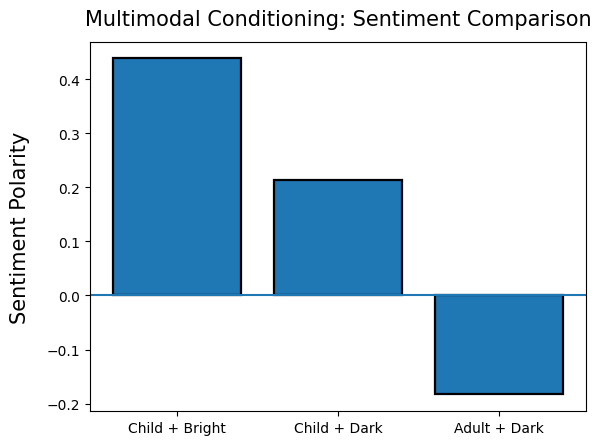

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Child + Bright", "Child + Dark", "Adult + Dark"]
sentiment_values = [0.438, 0.213, -0.183]

x = np.arange(len(labels))

plt.figure()
plt.bar(x, sentiment_values,edgecolor="black",linewidth=1.6)
plt.xticks(x, labels)
plt.title("Multimodal Conditioning: Sentiment Comparison",fontsize=15,pad=12)
plt.ylabel("Sentiment Polarity",fontsize=15,labelpad=12)
plt.axhline(0)  # Neutral line
plt.show()